notes dont delete:
- use bayth?
- remove shallower than 10m deep

explore the data a bit more:
- chlorophyll, sst, etc. for each month
- raw data

In [ ]:
# minmax to -1 to 1 standard deviation

In [1]:
# Import required libraries
import pickle
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter
import warnings

# Use seaborn style or default if preferred
plt.style.use('default')

In [2]:
# Load the pickle file
try:
    with open(r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl', 'rb') as f:
        data = pickle.load(f)

    df = data['data']
    metadata = data['metadata']
    print("Data loaded successfully.")
    
    # Extract coordinates
    lon_centers = np.array(metadata['lon_centers'])
    lat_centers = np.array(metadata['lat_centers'])
    if lon_centers.ndim == 1 and lat_centers.ndim == 1:
        lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)
    else:
        lon_grid_2d, lat_grid_2d = lon_centers, lat_centers
        
except FileNotFoundError:
    print("Data file not found. Please check path.")

Data loaded successfully.


In [6]:

target_year = 2018
months = range(1, 13)
month_data = {
    m: {'sst': [], 'chlor': [], 'ssl': []} for m in months
}

print(f"Processing data for {target_year}...")
for date_idx, row in df.iterrows():

    if date_idx.year != target_year:
        continue
        
    m = date_idx.month
    
    sst = row.get('sst')
    chlor = row.get('chlorophyll')
    ssl = row.get('ssl')

    # Basic validity checks
    if sst is None or chlor is None or ssl is None: continue
    if isinstance(sst, float) and np.isnan(sst): continue
    if isinstance(chlor, float) and np.isnan(chlor): continue
    if isinstance(ssl, float) and np.isnan(ssl): continue
    
    sst_arr = np.array(sst, dtype=float)
    chlor_arr = np.array(chlor, dtype=float)
    ssl_arr = np.array(ssl, dtype=float)
    
    # Process SSL (blur) as in the reference analysis to fill small gaps
    ssl_nan_mask = np.isnan(ssl_arr)
    if not ssl_nan_mask.all():
        ssl_filled = ssl_arr.copy()
        ssl_filled[ssl_nan_mask] = np.nanmean(ssl_arr)
        ssl_blurred = gaussian_filter(ssl_filled, sigma=2.0)
        ssl_blurred[ssl_nan_mask] = np.nan
        ssl_arr = ssl_blurred

    month_data[m]['sst'].append(sst_arr)
    month_data[m]['chlor'].append(chlor_arr)
    month_data[m]['ssl'].append(ssl_arr)

# Compute aggregated means
# This will now reflect only the selected year
monthly_means = {m: {} for m in months}
vars_to_aggregate = ['sst', 'chlor', 'ssl']

for m in months:
    for var in vars_to_aggregate:
        grids = month_data[m][var]
        if len(grids) > 0:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', category=RuntimeWarning)
                # Stack and Mean
                stack = np.stack(grids, axis=0)
                mean_grid = np.nanmean(stack, axis=0)
                monthly_means[m][var] = mean_grid
        else:
            monthly_means[m][var] = None

# Pre-calculate log10(chlor) for visualization
for m in months:
    if monthly_means[m]['chlor'] is not None:
        monthly_means[m]['log_chlor'] = np.log10(monthly_means[m]['chlor'])
    else:
        monthly_means[m]['log_chlor'] = None

print(f"Monthly means for {target_year} computed.")

Processing data for 2018...
Monthly means for 2018 computed.


Plotting Chlorophyll-a (Log Scale): vmin=-1.30, vmax=0.91


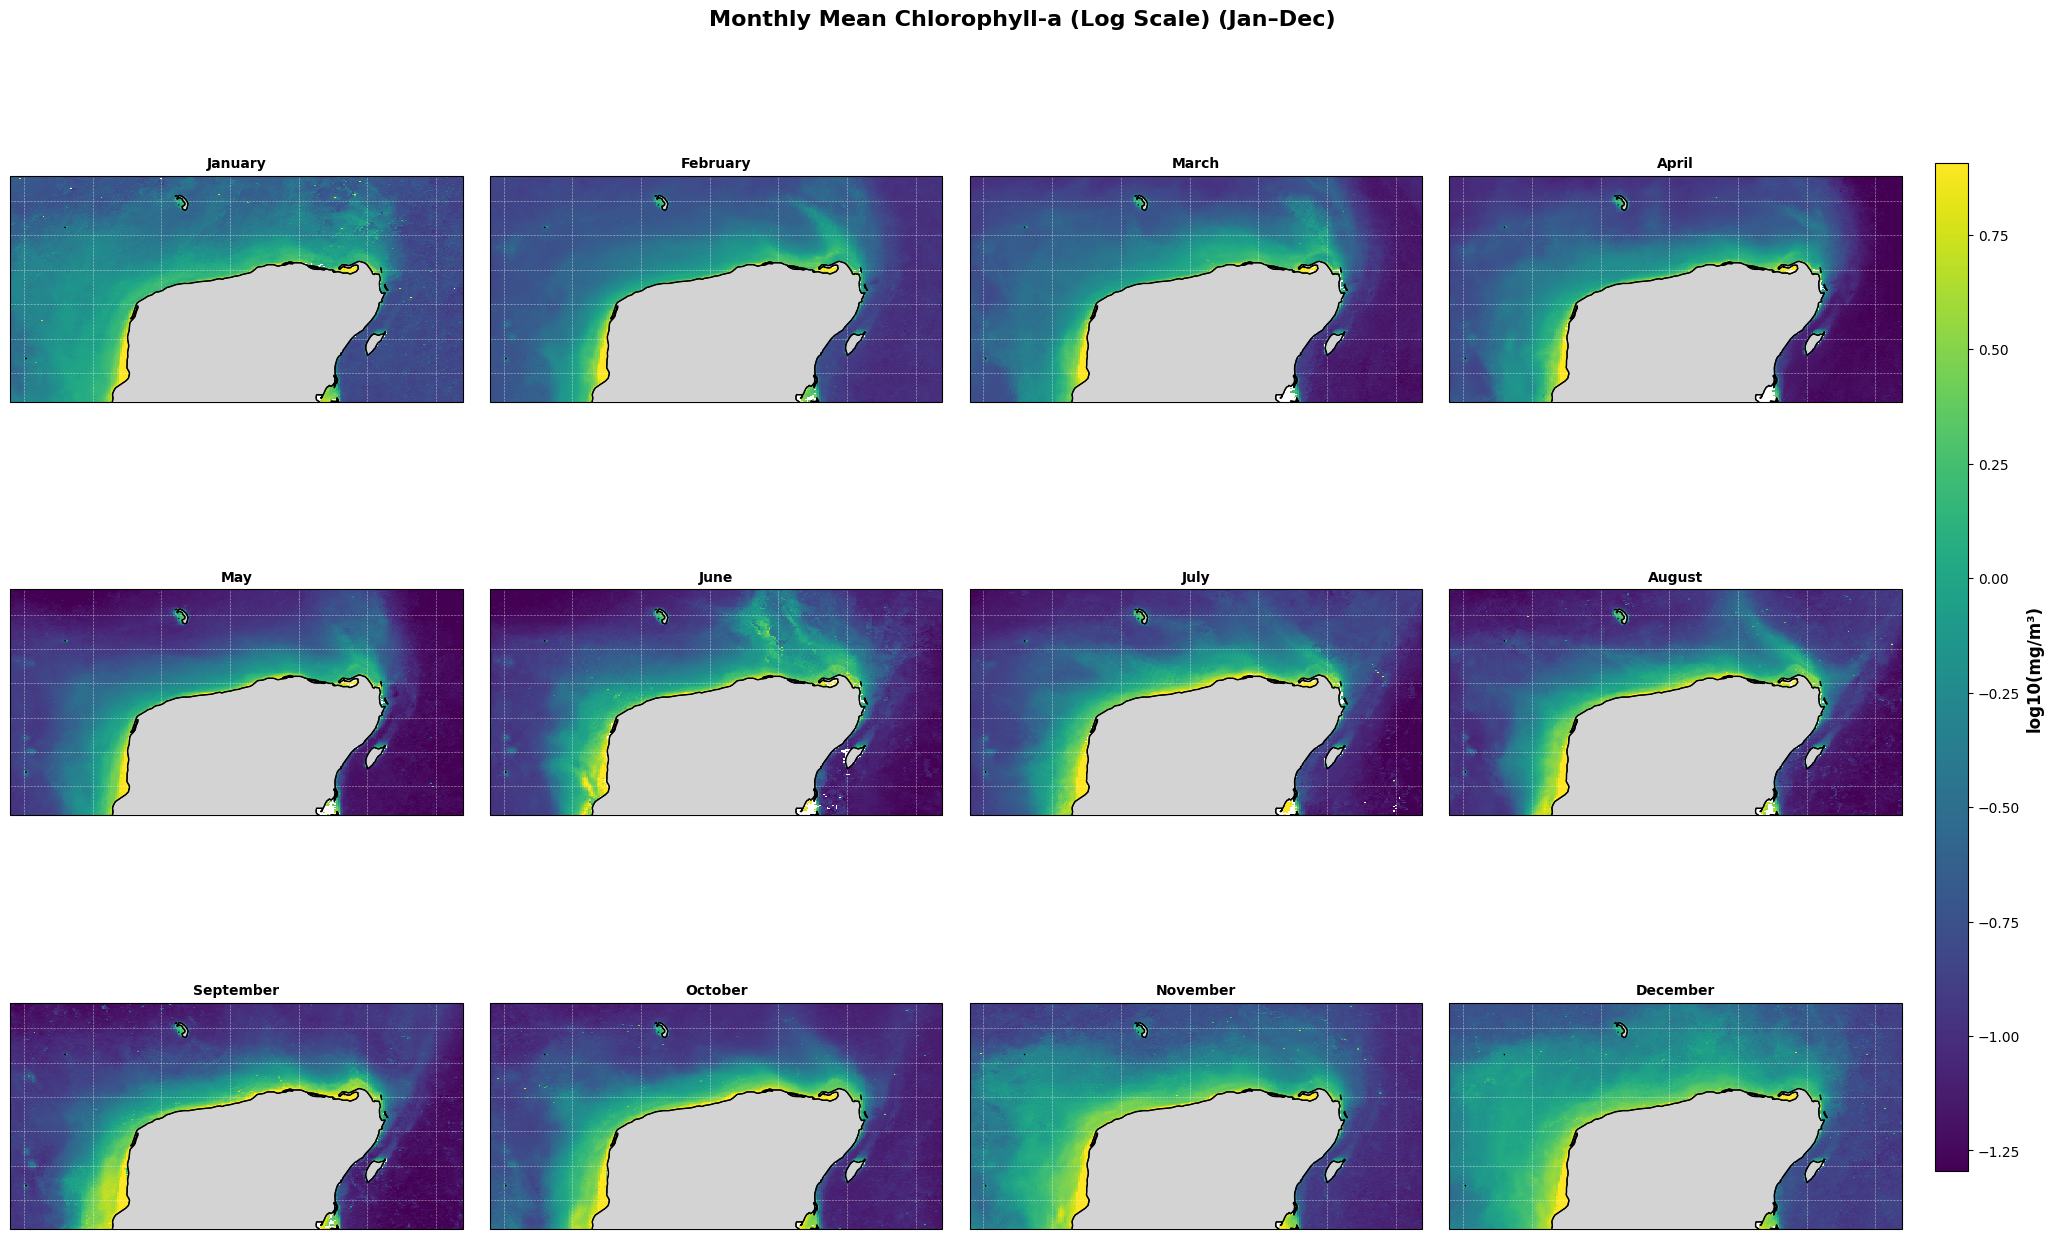

Plotting Sea Surface Temperature: vmin=23.62, vmax=30.16


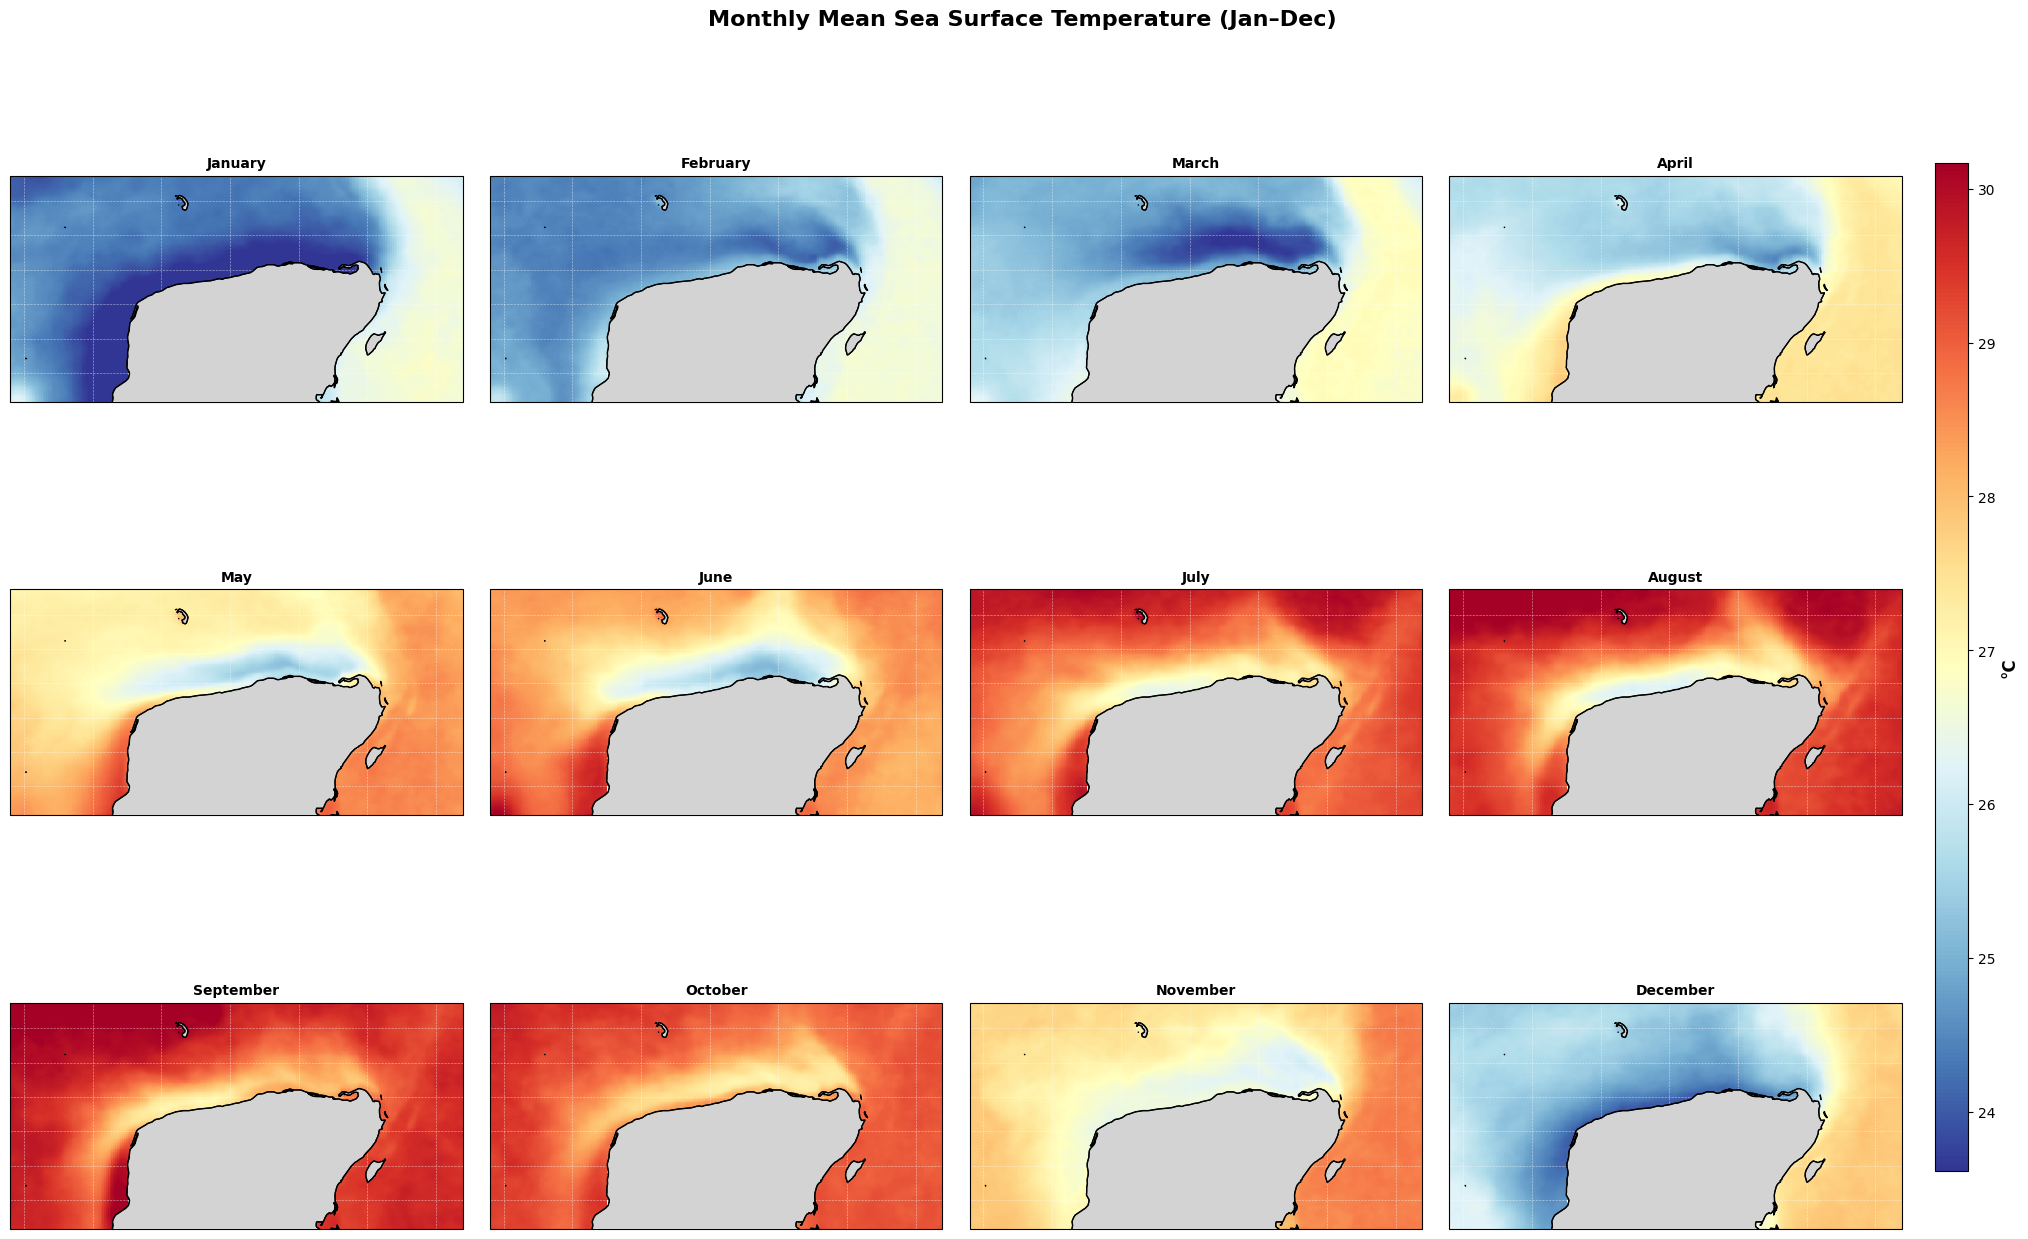

Plotting Sea Surface Level (SSL): vmin=0.18, vmax=0.85


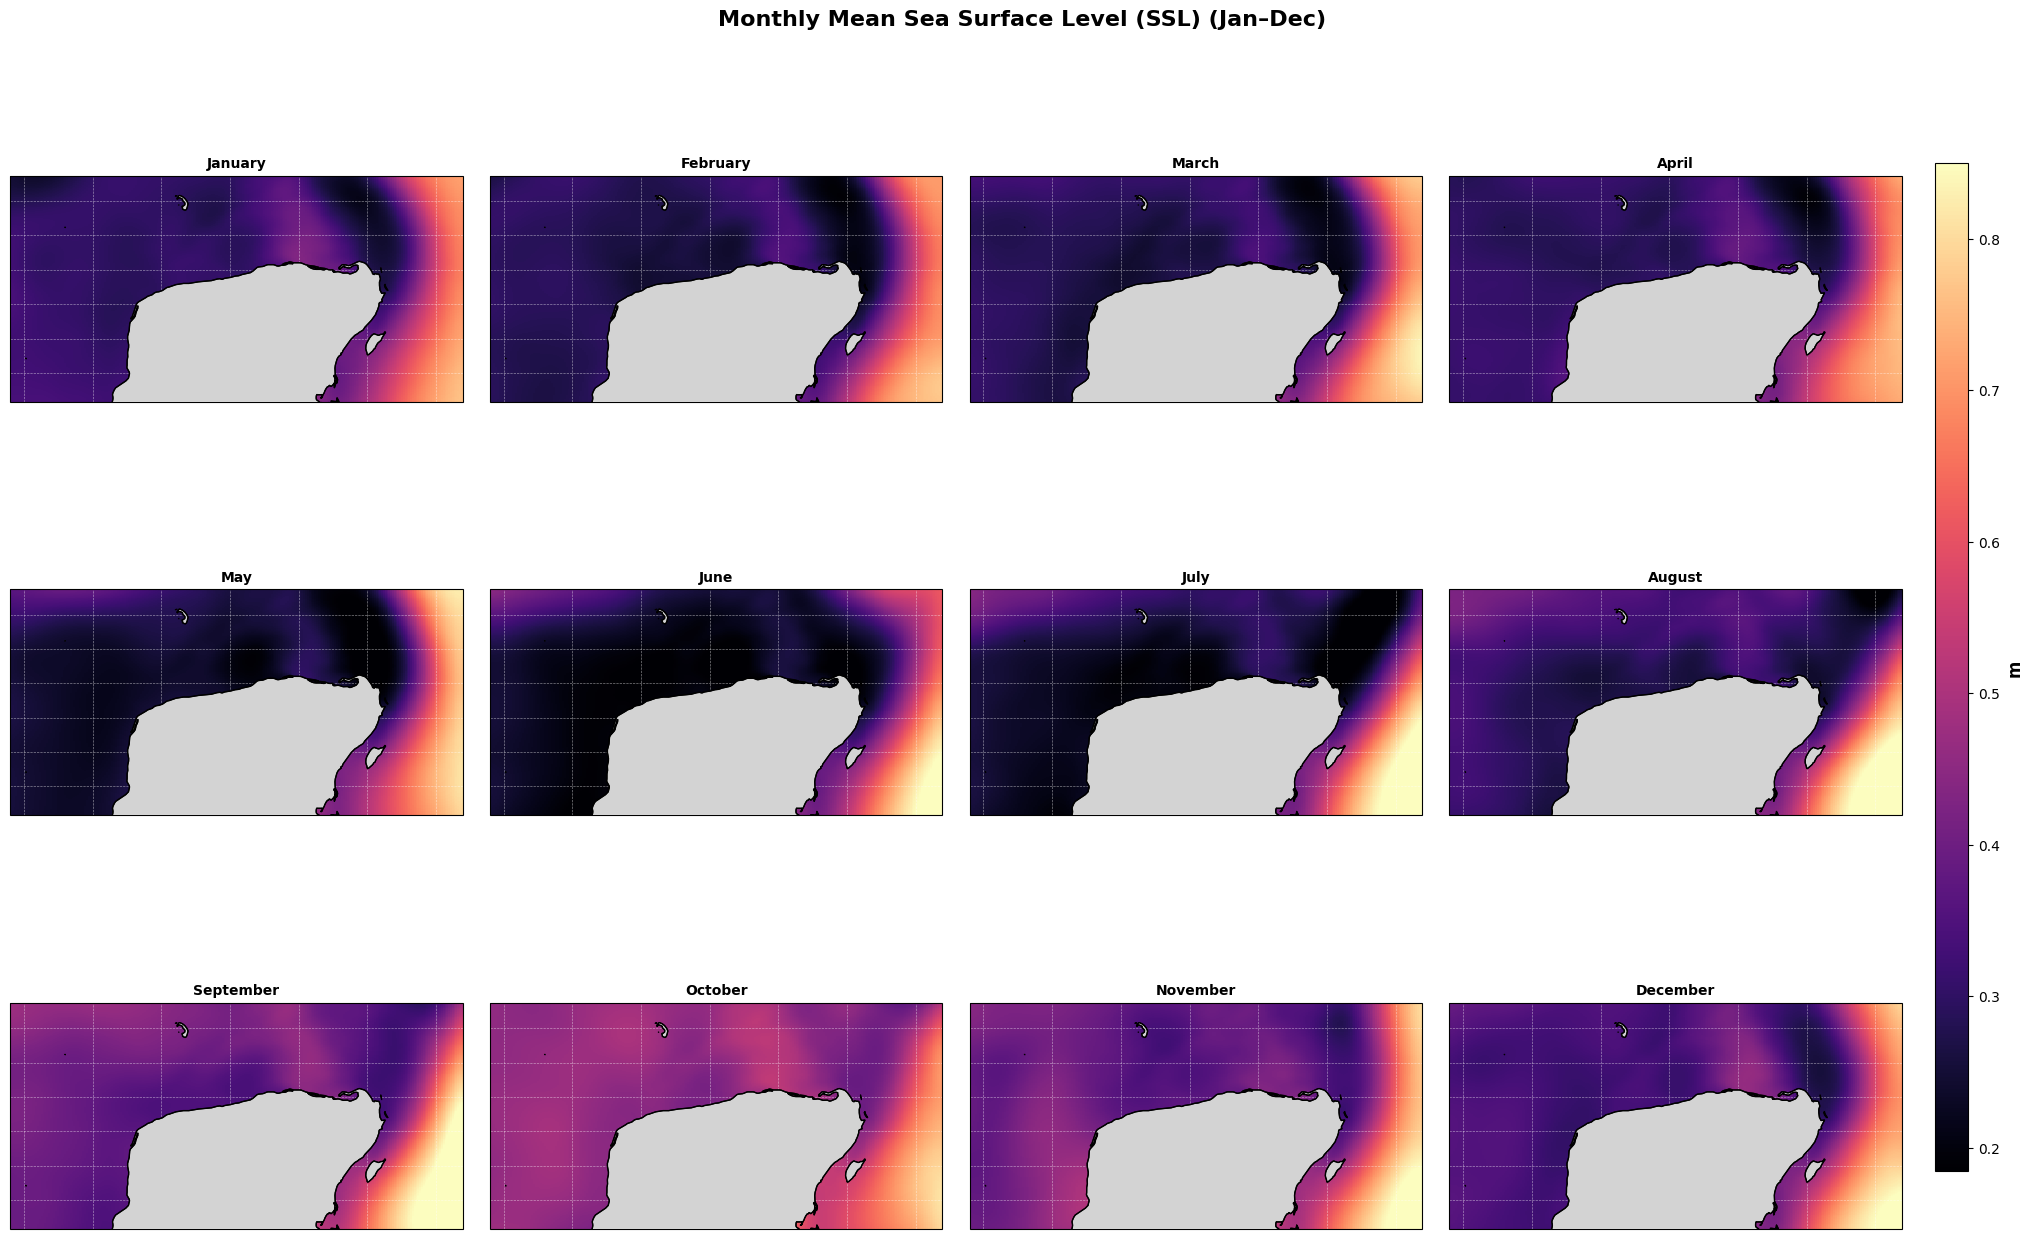

In [7]:
def plot_monthly_variable_raw(var_key, title_str, unit_label, cmap, vmin=None, vmax=None):
    month_names_full = ['January', 'February', 'March', 'April', 'May', 'June',
                        'July', 'August', 'September', 'October', 'November', 'December']
    
    # Region extent
    lat_min, lon_min = 19.57871, -92.20216
    lat_max, lon_max = 22.86906, -85.61256
    
    # Calculate global vmin/vmax if not provided, for consistent colorbar across months
    if vmin is None or vmax is None:
        all_vals = []
        for m in range(1, 13):
            grid = monthly_means[m].get(var_key)
            if grid is not None:
                all_vals.append(grid.flatten())
        if all_vals:
            all_vals = np.concatenate(all_vals)
            # Use percentiles to avoid extreme outliers skewing the plot
            if vmin is None: vmin = np.nanpercentile(all_vals, 1)
            if vmax is None: vmax = np.nanpercentile(all_vals, 99)
            
    print(f"Plotting {title_str}: vmin={vmin:.2f}, vmax={vmax:.2f}")

    fig, axes = plt.subplots(3, 4, figsize=(22, 14), subplot_kw={'projection': ccrs.PlateCarree()})
    
    mesh_for_cbar = None

    for month_num, ax in enumerate(axes.ravel(), start=1):
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        
        # Add map features
        ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.8, zorder=3)
        ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=4)
        ax.gridlines(draw_labels=False, linewidth=0.45, color='white', alpha=0.55, linestyle='--', zorder=2)
        
        data_grid = monthly_means[month_num].get(var_key)
        
        if data_grid is None:
            ax.set_title(f"{month_names_full[month_num-1]}\nNo Data", fontsize=10, fontweight='bold')
            continue
            
        mesh = ax.pcolormesh(
            lon_grid_2d, lat_grid_2d, data_grid,
            cmap=cmap, transform=ccrs.PlateCarree(),
            vmin=vmin, vmax=vmax, shading='auto', zorder=1
        )
        
        if mesh_for_cbar is None:
            mesh_for_cbar = mesh
            
        ax.set_title(f"{month_names_full[month_num-1]}", fontsize=10, fontweight='bold')

    # Shared Colorbar
    fig.subplots_adjust(left=0.04, right=0.90, bottom=0.05, top=0.90, wspace=0.06, hspace=0.14)
    if mesh_for_cbar is not None:
        cax = fig.add_axes([0.915, 0.14, 0.015, 0.72])
        cbar = fig.colorbar(mesh_for_cbar, cax=cax)
        cbar.set_label(unit_label, fontsize=12, weight='bold')

    fig.suptitle(f'Monthly Mean {title_str} (Jan–Dec)', fontsize=16, fontweight='bold', y=0.97)
    plt.show()

plot_monthly_variable_raw('log_chlor', 'Chlorophyll-a (Log Scale)', 'log10(mg/m³)', 'viridis')
plot_monthly_variable_raw('sst', 'Sea Surface Temperature', '°C', 'RdYlBu_r')
plot_monthly_variable_raw('ssl', 'Sea Surface Level (SSL)', 'm', 'magma')

In [10]:
import os
import matplotlib.animation as animation
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from datetime import timedelta

In [11]:
def create_daily_video(var_key, title_str, unit_label, cmap, vmin=None, vmax=None, window_days=14):
    """
    Generates a video for a specific variable for the target_year.
    Each frame is a sliding window average of `window_days` leading up to the current day.
    """
    output_dir = 'videos'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    output_path = os.path.join(output_dir, f'{var_key}_{target_year}_{window_days}day_avg.mp4')
    
    # We need a bit more data than just the target year for the first few days of January
    start_date = pd.Timestamp(year=target_year, month=1, day=1) - timedelta(days=window_days)
    end_date = pd.Timestamp(year=target_year, month=12, day=31)
    
    # Sort the dataframe to ensure chronological order
    full_df = df.sort_index()
    
    # Generate the target dates for 2018
    target_dates = pd.date_range(start=f"{target_year}-01-01", end=f"{target_year}-12-31", freq='D')
    
    valid_dates = []
    valid_grids = []
    
    print(f"Calculating 7-day sliding window for {var_key}...")
    
    for current_date in tqdm(target_dates):
        # Window range [current_date - 6 days, current_date]
        window_start = current_date - timedelta(days=window_days - 1)
        # Filter rows within the window
        mask = (full_df.index >= window_start) & (full_df.index <= current_date)
        window_rows = full_df.loc[mask]
        
        if window_rows.empty:
            continue
            
        grids_in_window = []
        for _, row in window_rows.iterrows():
            grid = row.get(var_key)
            if grid is None: continue
            if isinstance(grid, float) and np.isnan(grid): continue
            
            grid_arr = np.array(grid, dtype=float)
            
            # Pre-transform chlorophyll to log scale before averaging if desired
            # Usually it's better to average the raw values then log, or average the logs?
            # Scientific preference varies, but let's average then log for visualization consistency.
            
            if np.isnan(grid_arr).all(): continue
            
            # Apply SSL-like smoothing for SSL
            if var_key == 'ssl':
                nan_mask = np.isnan(grid_arr)
                if not nan_mask.all():
                    filled = grid_arr.copy()
                    filled[nan_mask] = np.nanmean(grid_arr)
                    grid_arr = gaussian_filter(filled, sigma=2.0)
                    grid_arr[nan_mask] = np.nan
            
            grids_in_window.append(grid_arr)
            
        if not grids_in_window:
            continue
            
        # Compute mean of the window
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', category=RuntimeWarning)
            avg_grid = np.nanmean(np.stack(grids_in_window), axis=0)
            
        if np.isnan(avg_grid).all():
            continue

        # Post-process for visualization
        if var_key == 'chlorophyll':
            # Handle zeros or negative values for log
            avg_grid = np.where(avg_grid > 0, avg_grid, np.nan)
            avg_grid = np.log10(avg_grid)
            
        valid_dates.append(current_date)
        valid_grids.append(avg_grid)
        
    if not valid_grids:
        print(f"No valid frames found for {var_key}")
        return

    # Determine limits
    if vmin is None or vmax is None:
        all_vals = np.concatenate([g.reshape(-1) for g in valid_grids])
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', category=RuntimeWarning)
            if vmin is None: vmin = float(np.nanpercentile(all_vals, 2))
            if vmax is None: vmax = float(np.nanpercentile(all_vals, 98))

    # Setup animation
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    
    lat_min, lon_min = 19.57871, -92.20216
    lat_max, lon_max = 22.86906, -85.61256
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=4)
    
    mesh = ax.pcolormesh(
        lon_grid_2d, lat_grid_2d, valid_grids[0],
        cmap=cmap, transform=ccrs.PlateCarree(),
        vmin=vmin, vmax=vmax, shading='auto', zorder=1
    )
    
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
    cbar = fig.colorbar(mesh, cax=cbar_ax)
    cbar_label = f"{unit_label} (log10 if chlor)"
    cbar.set_label(cbar_label, fontweight='bold')
    
    title = ax.set_title(f"{title_str} (7-Day Avg) - {valid_dates[0].strftime('%Y-%m-%d')}", fontweight='bold')

    def update(i):
        mesh.set_array(valid_grids[i].ravel())
        title.set_text(f"{title_str} (7-Day Avg) - {valid_dates[i].strftime('%Y-%m-%d')}")
        return mesh, title

    ani = animation.FuncAnimation(fig, update, frames=len(valid_grids), interval=100)
    
    print(f"Saving video to {output_path}...")
    try:
        ani.save(output_path, writer='ffmpeg', fps=10)
        print(f"Video saved: {output_path}")
    except Exception as e:
        print(f"Skipping save for {var_key} due to error: {e}")
    plt.close(fig)

# List of features to process
features = {
    'sst': {'title': 'Sea Surface Temperature', 'unit': '°C', 'cmap': 'RdYlBu_r'},
    'chlorophyll': {'title': 'Chlorophyll-a', 'unit': 'log10(mg/m³)', 'cmap': 'viridis'},
    'cdom_412': {'title': 'CDOM 412', 'unit': 'm⁻¹', 'cmap': 'plasma'},
    'cdom': {'title': 'CDOM', 'unit': 'm⁻¹', 'cmap': 'plasma'},
    'cdom_slope_275_295': {'title': 'CDOM Slope (275-295)', 'unit': 'nm⁻¹', 'cmap': 'inferno'},
    'cdom_slope_300_600': {'title': 'CDOM Slope (300-600)', 'unit': 'nm⁻¹', 'cmap': 'inferno'},
    'ssl': {'title': 'Sea Surface Level', 'unit': 'm', 'cmap': 'magma'}
}

for var, info in features.items():
    if var in df.columns:
        create_daily_video(var, info['title'], info['unit'], info['cmap'])
    else:
        print(f"Column {var} not found in dataframe.")

Calculating 7-day sliding window for sst...


  0%|          | 0/365 [00:00<?, ?it/s]

Saving video to videos\sst_2018_14day_avg.mp4...
Video saved: videos\sst_2018_14day_avg.mp4
Calculating 7-day sliding window for chlorophyll...


  0%|          | 0/365 [00:00<?, ?it/s]

Saving video to videos\chlorophyll_2018_14day_avg.mp4...
Video saved: videos\chlorophyll_2018_14day_avg.mp4
Calculating 7-day sliding window for cdom_412...


...

Saving video to videos\cdom_slope_275_295_2018_14day_avg.mp4...
Video saved: videos\cdom_slope_275_295_2018_14day_avg.mp4
Calculating 7-day sliding window for cdom_slope_300_600...


  0%|          | 0/365 [00:00<?, ?it/s]

Saving video to videos\cdom_slope_300_600_2018_14day_avg.mp4...
Video saved: videos\cdom_slope_300_600_2018_14day_avg.mp4
Calculating 7-day sliding window for ssl...


  0%|          | 0/365 [00:00<?, ?it/s]

Saving video to videos\ssl_2018_14day_avg.mp4...
Video saved: videos\ssl_2018_14day_avg.mp4
